# MedGemma — Results Analysis (for the paper)

Analysis of the held-out **test** run (`results/eval_predictions.jsonl`,
`eval_metrics.json`) plus the 3-way split composition. Produces the figures and
tables for the paper.

**How to run.** On Colab, run the Drive-mount cell; the split-distribution
section needs the `DatasetDict` on Drive. The test-set sections (confusion
matrices, calibration, findings) also run locally if `results/` is present.
Figures are written to `results/analysis/`.

Sections: (1) confusion matrices — BI-RADS, ACR density, per-finding;
(2) distribution of BI-RADS/ACR and DMID/VinDr across the 3 splits;
(3) calibration (reliability + ECE); (4) ordinal & clinical-safety metrics;
(5) metrics summary + per-source breakdown; (6) Methods text; (7) suggested
further analyses; (8) related-work metric comparison.

In [1]:
import json
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, cohen_kappa_score, confusion_matrix

SEED = 2

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
RESULTS_DIR = Path("/content/drive/MyDrive/MedGemma2026/main/results/final-run")

FIG_DIR = RESULTS_DIR / "analysis"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SPLIT_DIR = Path("/content/drive/MyDrive/MedGemma2026/main/data/split")

print("RESULTS_DIR:", RESULTS_DIR)
print("FIG_DIR    :", FIG_DIR)
print("SPLIT_DIR  :", SPLIT_DIR)

RESULTS_DIR: /content/drive/MyDrive/MedGemma2026/main/results/final-run
FIG_DIR    : /content/drive/MyDrive/MedGemma2026/main/results/final-run/analysis
SPLIT_DIR  : /content/drive/MyDrive/MedGemma2026/main/data/split


In [4]:
predictions = [json.loads(line) for line in open(RESULTS_DIR / "eval_predictions.jsonl")]
metrics = json.load(open(RESULTS_DIR / "eval_metrics.json"))
print(f"Loaded {len(predictions)} test predictions and the metrics summary.")

Loaded 1000 test predictions and the metrics summary.


In [5]:
# Extraction helpers (mirror the eval notebook)
def birads_main(text):
    """Primary BI-RADS integer category 1-5 (first value after the header)."""
    m = re.search(r"BI[-\s]?RADS:\s*([0-6])", text, re.IGNORECASE)
    return int(m.group(1)) if m else None


def extract_acr(text):
    m = re.search(r"\(ACR[\s-]+([A-D])\s*\)", text, re.IGNORECASE)
    return m.group(1).upper() if m else None


# Finding presence (negation-aware over the templated Findings bullets).
# Report scope is all finding types EXCEPT asymmetry (which a single view cannot
# establish); a negative case emits the single bullet "- No abnormal soft
# opacity.". The "no abnormal" entry in _NEG keeps that bullet from counting as a
# (soft-opacity) Mass.
FINDINGS = {
    "Mass": ["mass", "soft opacity", "opacit"],
    "Calcification": ["calcification", "calcium"],
    "Architectural distortion": ["architectural distortion", "distortion"],
    "Suspicious lymph node": ["lymph node", "adenopathy", "axillary node"],
    "Nipple retraction": ["nipple retraction"],
    "Skin retraction": ["skin retraction"],
    "Skin thickening": ["skin thickening"],
}
_NEG = ("no ", "appear normal", "appears normal", "unremarkable",
        "no significant", "no abnormal")


def finding_present(text, keys):
    for ln in text.lower().split("\n"):
        ln = ln.strip()
        if not ln.startswith("- "):
            continue
        body = ln[2:]
        hit = any(k in body for k in keys)
        if hit and any(n in body for n in _NEG):   # negated mention -> absent
            continue
        if hit:
            return True
    return False

## 1 · Confusion matrices

In [6]:
def plot_cm(y_true, y_pred, labels, title, fname, normalize=False):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = cm.astype(float)
    if normalize:
        disp = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    n = len(labels)
    fig, ax = plt.subplots(figsize=(1.4 + 0.7 * n, 1.4 + 0.7 * n))
    im = ax.imshow(disp, cmap="Blues", vmin=0, vmax=disp.max() if disp.max() else 1)
    ax.set_xticks(range(n)); ax.set_xticklabels(labels)
    ax.set_yticks(range(n)); ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Reference"); ax.set_title(title)
    thr = disp.max() / 2 if disp.max() else 0.5
    for i in range(n):
        for j in range(n):
            txt = f"{disp[i, j]:.2f}" if normalize else f"{cm[i, j]}"
            ax.text(j, i, txt, ha="center", va="center", fontsize=8,
                    color="white" if disp[i, j] > thr else "black")
    fig.colorbar(im, fraction=0.046, pad=0.04)
    fig.tight_layout()
    fig.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    return cm

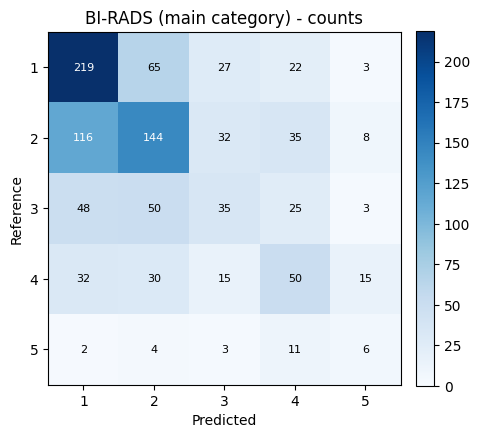

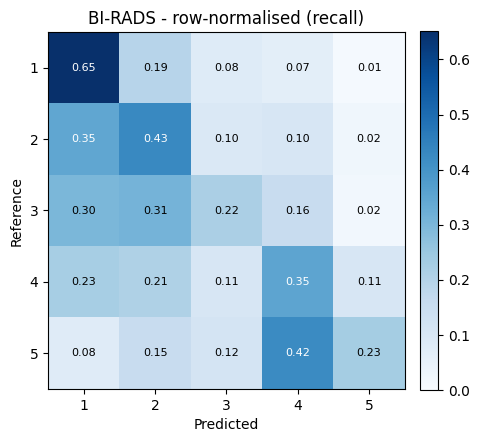

              precision    recall  f1-score   support

           1       0.53      0.65      0.58       336
           2       0.49      0.43      0.46       335
           3       0.31      0.22      0.26       161
           4       0.35      0.35      0.35       142
           5       0.17      0.23      0.20        26

    accuracy                           0.45      1000
   macro avg       0.37      0.38      0.37      1000
weighted avg       0.45      0.45      0.45      1000



In [7]:
bt = [birads_main(r["ref"]) for r in predictions]
bp = [birads_main(r["text"]) for r in predictions]
keep = [t is not None and p is not None for t, p in zip(bt, bp)]
bt = [t for t, k in zip(bt, keep) if k]
bp = [p for p, k in zip(bp, keep) if k]
BLAB = [1, 2, 3, 4, 5]
plot_cm(bt, bp, BLAB, "BI-RADS (main category) - counts", FIG_DIR / "cm_birads_counts.png")
plot_cm(bt, bp, BLAB, "BI-RADS - row-normalised (recall)", FIG_DIR / "cm_birads_recall.png", normalize=True)
print(classification_report(bt, bp, labels=BLAB, zero_division=0))

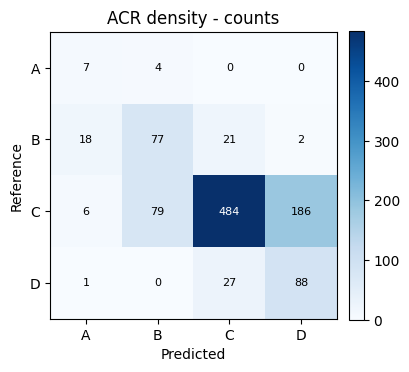

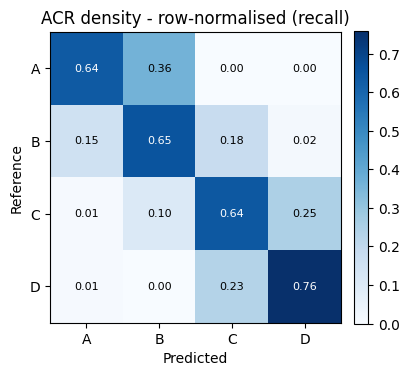

              precision    recall  f1-score   support

           A       0.22      0.64      0.33        11
           B       0.48      0.65      0.55       118
           C       0.91      0.64      0.75       755
           D       0.32      0.76      0.45       116

    accuracy                           0.66      1000
   macro avg       0.48      0.67      0.52      1000
weighted avg       0.78      0.66      0.69      1000



In [8]:
at = [extract_acr(r["ref"]) for r in predictions]
ap = [extract_acr(r["text"]) for r in predictions]
keep = [t in "ABCD" and p in "ABCD" for t, p in zip(at, ap)]
at = [t for t, k in zip(at, keep) if k]
ap = [p for p, k in zip(ap, keep) if k]
ALAB = ["A", "B", "C", "D"]
plot_cm(at, ap, ALAB, "ACR density - counts", FIG_DIR / "cm_acr_counts.png")
plot_cm(at, ap, ALAB, "ACR density - row-normalised (recall)", FIG_DIR / "cm_acr_recall.png", normalize=True)
print(classification_report(at, ap, labels=ALAB, zero_division=0))

finding                     ref+  pred+   TP   FP   FN     P     R    F1
Mass                         196    237   95  142  101  0.40  0.48  0.44
Calcification                 78     56   22   34   56  0.39  0.28  0.33
Architectural distortion      27      3    0    3   27  0.00  0.00  0.00
Suspicious lymph node         35     28   11   17   24  0.39  0.31  0.35
Nipple retraction              7      2    0    2    7  0.00  0.00  0.00
Skin retraction                3      2    1    1    2  0.50  0.33  0.40
Skin thickening               14     10    0   10   14  0.00  0.00  0.00


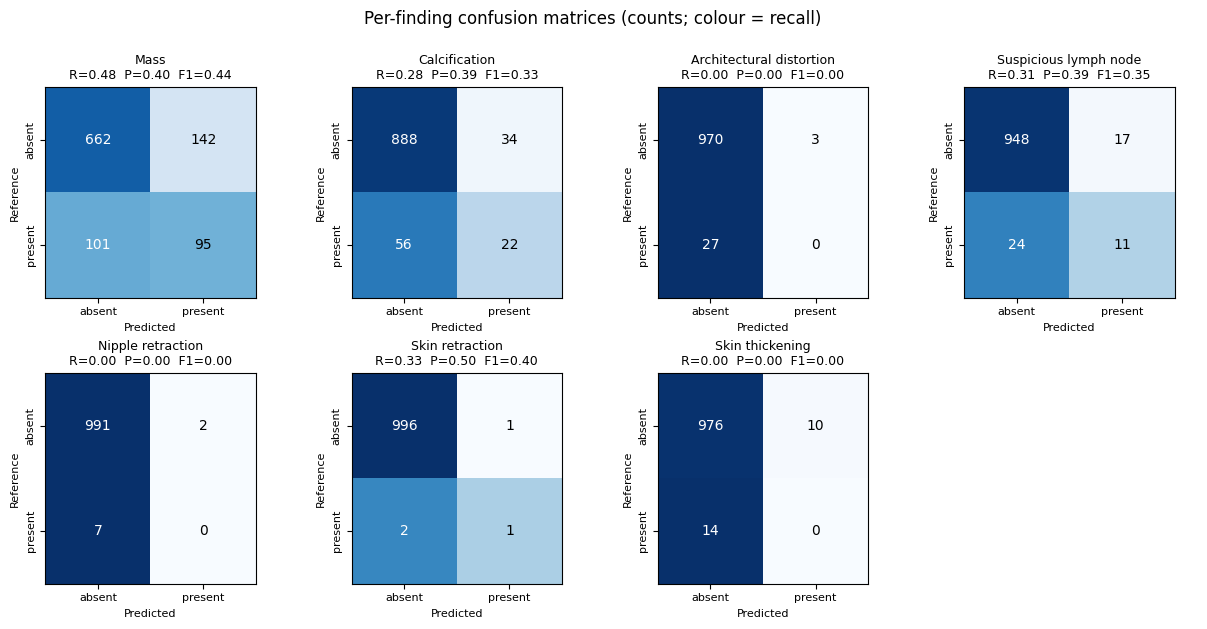

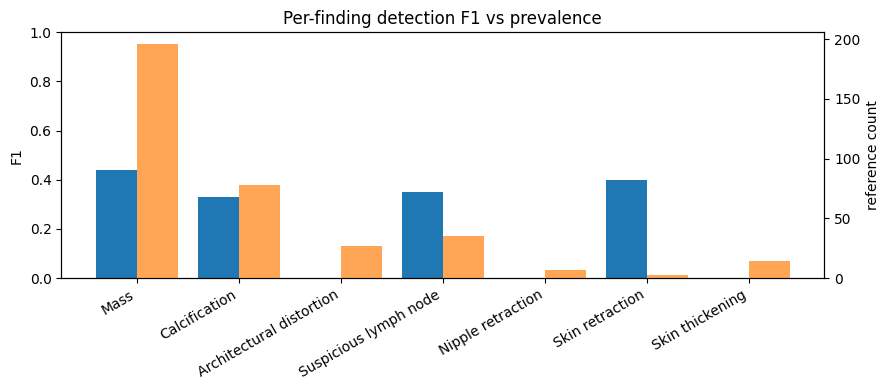

In [9]:
# Per-finding presence: precision / recall / F1 (multi-label, one-vs-rest)
# Findings are MULTI-LABEL (one image may have several), so each finding is its
# own binary present/absent decision -- there is no single multi-class matrix
# like BI-RADS/ACR. We print the P/R/F1 table AND plot one 2x2 confusion matrix
# per finding (counts annotated; colour = row-normalised so the huge TN cell
# does not wash out the off-diagonals).
print(f"{'finding':<26}{'ref+':>6}{'pred+':>7}{'TP':>5}{'FP':>5}{'FN':>5}"
      f"{'P':>6}{'R':>6}{'F1':>6}")
find_rows = []
for name, keys in FINDINGS.items():
    gt = np.array([finding_present(r["ref"], keys) for r in predictions])
    pr = np.array([finding_present(r["text"], keys) for r in predictions])
    tp = int((gt & pr).sum()); fp = int((~gt & pr).sum())
    fn = int((gt & ~pr).sum()); tn = int((~gt & ~pr).sum())
    P = tp / (tp + fp) if tp + fp else 0.0
    R = tp / (tp + fn) if tp + fn else 0.0
    F = 2 * P * R / (P + R) if P + R else 0.0
    find_rows.append((name, tp + fn, tp + fp, tp, fp, fn, tn, P, R, F))
    print(f"{name:<26}{tp + fn:>6}{tp + fp:>7}{tp:>5}{fp:>5}{fn:>5}{P:>6.2f}{R:>6.2f}{F:>6.2f}")

# Figure 1: per-finding 2x2 confusion matrices (present/absent).
LBL = ["absent", "present"]
ncol = 4
nrow = int(np.ceil(len(find_rows) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.1 * ncol, 3.1 * nrow))
axes = np.array(axes).reshape(-1)
for ax, (name, _rp, _pp, tp, fp, fn, tn, P, R, F) in zip(axes, find_rows):
    cm = np.array([[tn, fp], [fn, tp]])                  # rows=ref, cols=pred
    rown = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    ax.imshow(rown, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks([0, 1]); ax.set_xticklabels(LBL, fontsize=8)
    ax.set_yticks([0, 1]); ax.set_yticklabels(LBL, fontsize=8, rotation=90, va="center")
    ax.set_xlabel("Predicted", fontsize=8); ax.set_ylabel("Reference", fontsize=8)
    ax.set_title(f"{name}\nR={R:.2f}  P={P:.2f}  F1={F:.2f}", fontsize=9)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=10,
                    color="white" if rown[i, j] > 0.5 else "black")
for ax in axes[len(find_rows):]:
    ax.axis("off")
fig.suptitle("Per-finding confusion matrices (counts; colour = recall)", y=1.0)
fig.tight_layout()
fig.savefig(FIG_DIR / "cm_findings.png", dpi=150, bbox_inches="tight")
plt.show()

# Figure 2: per-finding F1 + reference prevalence.
names = [r[0] for r in find_rows]
f1s = [r[9] for r in find_rows]
prev = [r[1] for r in find_rows]
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(names))
ax.bar(x - 0.2, f1s, 0.4, label="F1", color="tab:blue")
ax2 = ax.twinx()
ax2.bar(x + 0.2, prev, 0.4, label="ref prevalence (n)", color="tab:orange", alpha=0.7)
ax.set_xticks(x); ax.set_xticklabels(names, rotation=30, ha="right")
ax.set_ylabel("F1"); ax2.set_ylabel("reference count"); ax.set_ylim(0, 1)
ax.set_title("Per-finding detection F1 vs prevalence")
fig.tight_layout(); fig.savefig(FIG_DIR / "findings_f1.png", dpi=150, bbox_inches="tight")
plt.show()


## 2 · Distribution across the 3 splits

Needs the split `DatasetDict` on Drive. Each record carries `source`
(`dmid` / `vindr-mammo`) and `birads_strata`, so we can cross-tabulate.

In [10]:
from datasets import load_from_disk

dsd = load_from_disk(str(SPLIT_DIR))
print({k: len(v) for k, v in dsd.items()})

{'train': 3670, 'validation': 1000, 'test': 1000}


BI-RADS strata per split:
  stratum        train  validation        test
  1                700         336         336
  2                700         335         335
  3                735         158         158
  4                535         115         115
  4a               150           6           6
  4b               150           5           5
  4c               200           8           8
  5                500          37          37

ACR density per split:
  acr            train  validation        test
  A                526           9          11
  B               1187         119         118
  C               1152         756         755
  D                805         116         116


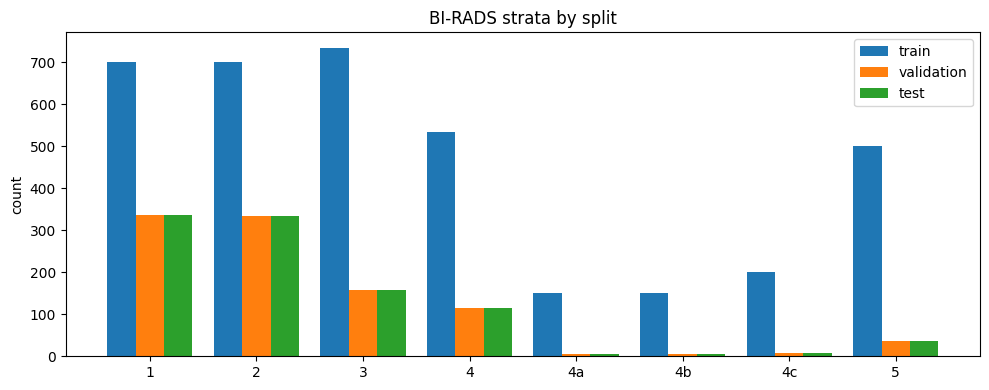

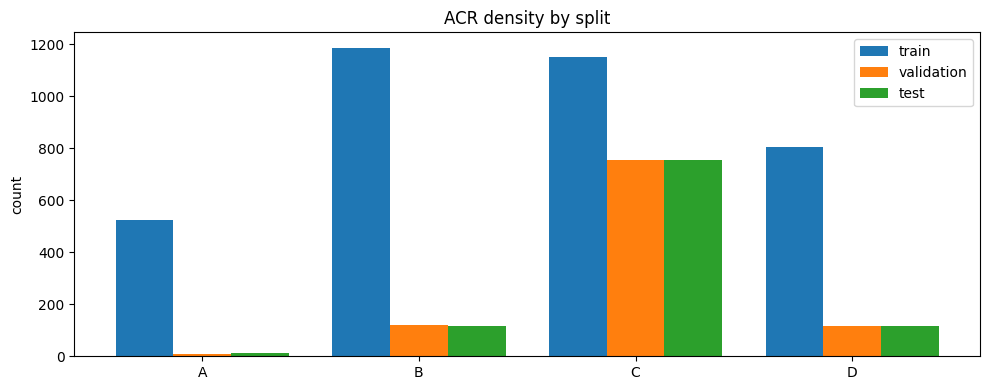

In [11]:
STRATA_ORDER = ["1", "2", "3", "4", "4a", "4b", "4c", "5"]
ACR_ORDER = ["A", "B", "C", "D"]


def grouped_bar(counts_by_split, order, title, ylabel, fname):
    splits = list(counts_by_split.keys())
    x = np.arange(len(order)); w = 0.8 / len(splits)
    fig, ax = plt.subplots(figsize=(10, 4))
    for i, s in enumerate(splits):
        vals = [counts_by_split[s].get(k, 0) for k in order]
        ax.bar(x + i * w - 0.4 + w / 2, vals, w, label=s)
    ax.set_xticks(x); ax.set_xticklabels(order)
    ax.set_ylabel(ylabel); ax.set_title(title); ax.legend()
    fig.tight_layout(); fig.savefig(fname, dpi=150, bbox_inches="tight"); plt.show()


bi = {s: Counter(dsd[s]["birads_strata"]) for s in dsd}
# birads_strata is a ClassLabel (int) -> map back to names
feat = dsd["train"].features["birads_strata"]
bi = {s: Counter(feat.int2str(int(v)) for v in dsd[s]["birads_strata"]) for s in dsd}
acr = {s: Counter(dsd[s]["acr_density"]) for s in dsd}
afeat = dsd["train"].features["acr_density"]
acr = {s: Counter(afeat.int2str(int(v)) for v in dsd[s]["acr_density"]) for s in dsd}

print("BI-RADS strata per split:")
print(f"  {'stratum':<8}" + "".join(f"{s:>12}" for s in dsd))
for k in STRATA_ORDER:
    print(f"  {k:<8}" + "".join(f"{bi[s].get(k,0):>12}" for s in dsd))
print("\nACR density per split:")
print(f"  {'acr':<8}" + "".join(f"{s:>12}" for s in dsd))
for k in ACR_ORDER:
    print(f"  {k:<8}" + "".join(f"{acr[s].get(k,0):>12}" for s in dsd))

grouped_bar(bi, STRATA_ORDER, "BI-RADS strata by split", "count", FIG_DIR / "dist_birads_splits.png")
grouped_bar(acr, ACR_ORDER, "ACR density by split", "count", FIG_DIR / "dist_acr_splits.png")

Source per split (records; note train may include oversampled copies):
  source               train  validation        test
  dmid                  1028          77          72
  vindr-mammo           2642         923         928

Unique dmid ids per split:
  train       : 1028 total, 358 unique
  validation  : 77 total, 77 unique
  test        : 72 total, 72 unique


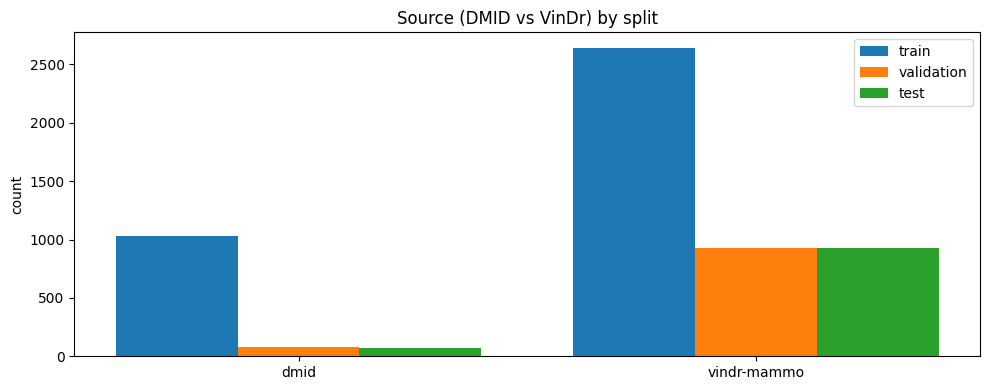

In [12]:
src = {s: Counter(dsd[s]["source"]) for s in dsd}
sources = ["dmid", "vindr-mammo"]
print("Source per split (records; note train may include oversampled copies):")
print(f"  {'source':<14}" + "".join(f"{s:>12}" for s in dsd))
for k in sources:
    print(f"  {k:<14}" + "".join(f"{src[s].get(k,0):>12}" for s in dsd))
print("\nUnique dmid ids per split:")
for s in dsd:
    ids = [i for i, so in zip(dsd[s]["id"], dsd[s]["source"]) if so == "dmid"]
    print(f"  {s:<12}: {len(ids)} total, {len(set(ids))} unique")
grouped_bar(src, sources, "Source (DMID vs VinDr) by split", "count", FIG_DIR / "dist_source_splits.png")

In [13]:
bfeat = dsd["train"].features["birads_strata"]
afeat = dsd["train"].features["acr_density"]
_b = lambda v: bfeat.int2str(int(v)) if isinstance(v, int) else (v or "?")
_a = lambda v: afeat.int2str(int(v)) if isinstance(v, int) else (v or "?")

cells = {}                      # (split, source, birads, acr) -> [total, {ids}]
for split in dsd:
    ds = dsd[split]
    for _id, so, bv, av in zip(ds["id"], ds["source"],
                                ds["birads_strata"], ds["acr_density"]):
        c = cells.setdefault((split, so, _b(bv), _a(av)), [0, set()])
        c[0] += 1
        c[1].add(_id)

rows = [(s, so, b, a, len(ids), tot, tot - len(ids))
        for (s, so, b, a), (tot, ids) in cells.items()]
ob = {v: i for i, v in enumerate(STRATA_ORDER)}
SPL = ["train", "validation", "test"]
rows.sort(key=lambda r: (SPL.index(r[0]), r[1], ob.get(r[2], 99), r[3]))

hdr = (f"{'split':<11}{'source':<13}{'birads':<7}{'acr':<5}"
        f"{'original':>9}{'final':>7}{'augmented':>11}")
print(hdr); print("-" * len(hdr))
for s, so, b, a, orig, tot, aug in rows:
    print(f"{s:<11}{so:<13}{b:<7}{a:<5}{orig:>9}{tot:>7}{aug:>11}"
          + ("  <- oversampled" if aug else ""))

# Roll-ups by BI-RADS and by ACR (train only -- the only augmented split).
for idx, label in [(2, "BI-RADS"), (3, "ACR")]:
    agg = {}
    for r in rows:
        if r[0] != "train":
            continue
        o, t = agg.get(r[idx], (0, 0))
        agg[r[idx]] = (o + r[4], t + r[5])
    keys = (STRATA_ORDER if label == "BI-RADS" else ACR_ORDER)
    print(f"\nTRAIN by {label}:")
    for k in keys:
        if k in agg:
            o, t = agg[k]
            print(f"  {k:<6} original={o:>6}  final={t:>6}  augmented={t - o:>6}")

print("\n" + "=" * 52)
for split in SPL:
    o = sum(r[4] for r in rows if r[0] == split)
    t = sum(r[5] for r in rows if r[0] == split)
    print(f"{split:<12} original(unique)={o:>6}  final={t:>6}  augmented={t - o:>6}")


split      source       birads acr   original  final  augmented
---------------------------------------------------------------
train      dmid         1      A           24     43         19  <- oversampled
train      dmid         1      B           66     66          0
train      dmid         1      C           44     44          0
train      dmid         1      D           13     13          0
train      dmid         2      A            7     42         35  <- oversampled
train      dmid         2      B            6      6          0
train      dmid         2      C            4      4          0
train      dmid         3      A           12     72         60  <- oversampled
train      dmid         3      B           24     95         71  <- oversampled
train      dmid         3      C           43     43          0
train      dmid         3      D            7     21         14  <- oversampled
train      dmid         4      B            1      4          3  <- oversampled
train   

## 3 · Calibration (reliability + ECE)

Uses the closed-set probabilities saved per prediction. BI-RADS calibration is
on the main category for single-category references.

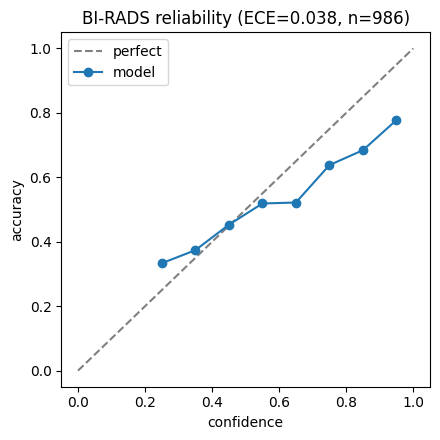

BI-RADS: ECE = 0.0383  (n=986)


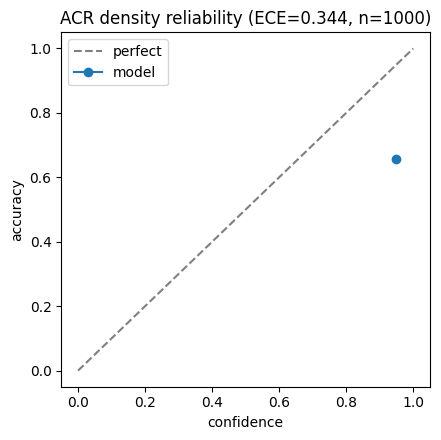

ACR density: ECE = 0.3440  (n=1000)


np.float64(0.34399907135963437)

In [14]:
def expected_calibration_error(confs, correct, n_bins=10):
    confs = np.asarray(confs, float); correct = np.asarray(correct, float)
    bins = np.linspace(0, 1, n_bins + 1); ece = 0.0; rows_ = []; n = len(confs)
    for b in range(n_bins):
        lo, hi = bins[b], bins[b + 1]
        m = (confs > lo) & (confs <= hi) if b else (confs >= lo) & (confs <= hi)
        if m.sum() == 0:
            rows_.append((lo, hi, 0, np.nan, np.nan)); continue
        c = float(confs[m].mean()); a = float(correct[m].mean())
        ece += m.sum() / n * abs(a - c); rows_.append((lo, hi, int(m.sum()), c, a))
    return ece, rows_


def _true_main(ref):
    cats = re.findall(r"[1-5]", re.search(r"BI[-\s]?RADS:\s*(.+?)(?:\n|$)", ref, re.I).group(1)) \
        if re.search(r"BI[-\s]?RADS:", ref, re.I) else []
    return cats[0] if len(set(cats)) == 1 else None


def reliability(field, true_fn, name, fname):
    confs, correct = [], []
    for r in predictions:
        sc = r.get(field)
        if not sc:
            continue
        true = true_fn(r["ref"])
        if true is None:
            continue
        confs.append(sc["conf"]); correct.append(sc["pred"] == true)
    ece, tbl = expected_calibration_error(confs, correct)
    xs = [(lo + hi) / 2 for lo, hi, c, cf, a in tbl if c]
    accs = [a for lo, hi, c, cf, a in tbl if c]
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    ax.plot([0, 1], [0, 1], "--", color="grey", label="perfect")
    ax.plot(xs, accs, "o-", label="model")
    ax.set_xlabel("confidence"); ax.set_ylabel("accuracy")
    ax.set_title(f"{name} reliability (ECE={ece:.3f}, n={len(confs)})")
    ax.legend(); fig.tight_layout()
    fig.savefig(fname, dpi=150, bbox_inches="tight"); plt.show()
    print(f"{name}: ECE = {ece:.4f}  (n={len(confs)})")
    return ece


reliability("birads", _true_main, "BI-RADS", FIG_DIR / "calib_birads.png")
reliability("acr", lambda ref: extract_acr(ref) if extract_acr(ref) in "ABCD" else None,
            "ACR density", FIG_DIR / "calib_acr.png")

## 4 · Ordinal & clinical-safety metrics

BI-RADS and ACR are ordinal, so exact-match accuracy understates agreement.
We add quadratic-weighted Cohen's kappa and within-+/-1 accuracy, plus a
clinically critical **under-call** rate (a malignant/suspicious reference
reported as benign).

In [15]:
def ordinal_report(y_true, y_pred, order, name):
    idx = {v: i for i, v in enumerate(order)}
    yt = np.array([idx[v] for v in y_true]); yp = np.array([idx[v] for v in y_pred])
    qwk = cohen_kappa_score(yt, yp, weights="quadratic")
    within1 = float((np.abs(yt - yp) <= 1).mean())
    exact = float((yt == yp).mean())
    print(f"{name}: exact={exact:.3f}  within-1={within1:.3f}  quadratic-weighted kappa={qwk:.3f}")
    return exact, within1, qwk


ordinal_report(bt, bp, BLAB, "BI-RADS")
ordinal_report(at, ap, ALAB, "ACR density")

SUSPICIOUS = {4, 5}     # 4x folds into 4; 3 is "probably benign"
BENIGN = {1, 2}
under = sum(t in SUSPICIOUS and p in BENIGN for t, p in zip(bt, bp))
over = sum(t in BENIGN and p in SUSPICIOUS for t, p in zip(bt, bp))
n_susp = sum(t in SUSPICIOUS for t in bt)
n_ben = sum(t in BENIGN for t in bt)
print(f"\nUnder-call (ref BI-RADS 4/5 -> pred 1/2): {under}/{n_susp} = {under / max(n_susp,1):.3f}")
print(f"Over-call  (ref BI-RADS 1/2 -> pred 4/5): {over}/{n_ben} = {over / max(n_ben,1):.3f}")

BI-RADS: exact=0.454  within-1=0.783  quadratic-weighted kappa=0.408
ACR density: exact=0.656  within-1=0.991  quadratic-weighted kappa=0.555

Under-call (ref BI-RADS 4/5 -> pred 1/2): 68/168 = 0.405
Over-call  (ref BI-RADS 1/2 -> pred 4/5): 68/671 = 0.101


## 5 · Metrics summary + per-source breakdown

The headline numbers (from `eval_metrics.json`), and -- on Colab -- the same
metrics split by data source (DMID vs VinDr), joining predictions to the test
split by index.

In [16]:
def show(d, pre=""):
    for k, v in d.items():
        if isinstance(v, dict):
            print(f"{pre}{k}:"); show(v, pre + "  ")
        else:
            print(f"{pre}{k}: {v}")
print("=== eval_metrics.json ===")
show(metrics)

=== eval_metrics.json ===
text:
  rouge:
    rouge1: 0.8048283389367151
    rouge2: 0.706419638792247
    rougeL: 0.8023861764933197
    rougeLsum: 0.8043262592126651
  rougeL_ci: [0.8023861764933197, 0.7916142470736989, 0.8141055513097867]
  bleu:
    bleu_1: 0.8300386048903047
    bleu_2: 0.7869805163375496
    bleu_3: 0.7497494837583248
    bleu_4: 0.7165922345322407
  meteor: 0.8388466944325635
  word_level_f1:
    precision: 0.7994765036694353
    recall: 0.8003170083697495
    f1: 0.7969512053255099
birads:
  accuracy_ci: [0.437, 0.406975, 0.469]
  macro_f1_ci: [0.18929271036306172, 0.15195320230587359, 0.26554489326515707]
  balanced_accuracy_ci: [0.231186830373671, 0.1842701992663577, 0.32087933743799274]
acr_density:
  accuracy_ci: [0.656, 0.626975, 0.685]
  macro_f1_ci: [0.5201636434636745, 0.46616445744631335, 0.5748429376444681]
  balanced_accuracy_ci: [0.6721465753872928, 0.5890689475741075, 0.745217211410561]
probability_coverage:
  birads: 1000
  acr: 1000
  n: 1000
num_

In [ ]:
from sklearn.metrics import accuracy_score

test = dsd["test"]
src_of = list(test["source"])               # row i of predictions == test[i]
assert len(src_of) == len(predictions), "prediction/test length mismatch"
for source in ["dmid", "vindr-mammo"]:
    sub = [r for r, s in zip(predictions, src_of) if s == source]
    if not sub:
        continue
    tb = [birads_main(r["ref"]) for r in sub]; pb = [birads_main(r["text"]) for r in sub]
    ta = [extract_acr(r["ref"]) or "?" for r in sub]; pa = [extract_acr(r["text"]) or "?" for r in sub]
    b_acc = accuracy_score(tb, pb); a_acc = accuracy_score(ta, pa)
    print(f"[{source}] n={len(sub)}  BI-RADS acc={b_acc:.3f}  ACR acc={a_acc:.3f}")

[dmid] n=72  BI-RADS acc=0.583  ACR acc=0.625
[vindr-mammo] n=928  BI-RADS acc=0.444  ACR acc=0.658


## 6 · Methods (paper text)

### 6.1 Image preprocessing
DMID images (`.tif`) were converted to 8-bit PNG with the Mammo-CLIP
preprocessing pipeline: a 5-pixel border crop, min-max rescaling to 8-bit, a
breast-region crop (largest connected component of the thresholded foreground),
and resizing to 912x1520 with area interpolation. VinDr-Mammo used the publicly
released Mammo-CLIP PNGs (already breast-cropped, 8-bit, 912x1520). At
train/eval time images were converted to RGB and down-scaled so the longest side
is <= 512 px (LANCZOS).

### 6.2 Report processing
DMID's free-text reports were reformatted into a canonical template:
`Breast Composition: <density> (ACR <A-D>).`, a `BI-RADS:` line, and a `Findings:`
bullet list. VinDr-Mammo reports were synthesised from the breast-level and
finding annotations into the **same** template, so the two corpora share a single
surface form. The Findings section renders every reported finding type (mass,
suspicious calcification, architectural distortion, suspicious lymph node, and
skin/nipple changes) **except asymmetry**, which is ignored because a single
mammographic view cannot establish it; a case with no remaining finding emits the
single bullet `- No abnormal soft opacity.`. No case is dropped on account of its
findings — only reports that fail to parse, carry no BI-RADS category, or lack an ACR density marker are
excluded, and BI-RADS 0 and 6 are filtered in the split (neither dataset uses them here).

### 6.3 Dataset unification and split
The merged corpus was split stratified by BI-RADS. All DMID records were split
across train/val/test by a 70/15/15 ratio and never discarded; VinDr-Mammo
records then filled each split to its target size. Validation and test were fixed
at 1000 records each, with BI-RADS 1 and 2 sized as `(1000 - n(other strata))/2`
(even split). The training split was rebalanced with a nested **BI-RADS-primary,
ACR-secondary** scheme: BI-RADS 1 and 2 were capped and 5/4a/4b/4c oversampled to
target counts, and within each BI-RADS stratum the ACR density mix (A/B/C/D) was
evened toward uniform (oversampling capped per stratum-density cell, with unmet
quota redistributed so the BI-RADS target is still met). Validation and test were
left at their representative density distribution for honest evaluation. Augmentation was applied online to the oversampled duplicate copies only (horizontal flip; small translation/scale; no rotation, since mammograms are anatomically aligned); the original copy of each case was kept unaugmented.

### 6.4 Model and fine-tuning
We fine-tuned MedGemma 1.5 4B-it with QLoRA (4-bit NF4 weights, bf16 compute),
LoRA rank 16 on all linear layers plus the LM head and token embeddings,
effective batch size 128, and early stopping on validation loss. A fixed
zero-shot structured prompt specified the ACR and BI-RADS lexicons and the exact
output format.

### 6.5 Metric computation
Text quality: ROUGE-1/2/L, BLEU-1..4, METEOR, and a token-level Word-F1
(precision/recall/F1 over lowercased tokens) via HuggingFace `evaluate`. BI-RADS
and ACR labels were parsed from the generated report by regular expression and
scored with accuracy, macro-F1, balanced accuracy, and per-class
precision/recall/F1; 95% confidence intervals were obtained by bootstrap
resampling (1000 replicates). Per-finding presence was derived from the Findings
bullets with negation handling and scored one-vs-rest.

### 6.6 Confidence (closed-set scoring) and calibration
During greedy decoding we retained the per-step output logits. For each report we
located the token at which the model commits the ACR letter and the BI-RADS
category (by aligning a cumulative decode of the generated tokens to the text),
and applied a softmax over **only** the valid class tokens ({A,B,C,D};
{1,2,3,4,5}) to obtain a normalised class distribution and its confidence.
Calibration was assessed with the Expected Calibration Error and reliability
diagrams; an optional single-temperature scaling was fit on validation.

## 7 · Suggested additional analyses

Beyond the four you listed, these strengthen a medical-imaging paper:

- **Ordinal agreement** (Section 4): quadratic-weighted kappa and within-+/-1
  accuracy -- standard in radiology AI and fairer than exact match for ordinal
  BI-RADS/density.
- **Clinical-safety errors** (Section 4): malignant/suspicious under-call rate is
  the number reviewers care about most; report it explicitly.
- **Calibration** (Section 3): reliability + ECE; highlight ACR over-confidence
  and the effect of temperature scaling.
- **Selective prediction / risk-coverage:** accuracy as a function of a
  confidence threshold -- shows whether the confidence can triage cases.
- **Per-source generalisation** (Section 5): DMID-only vs VinDr-only test metrics.
- **Format validity:** fraction of generated reports that parse (valid `BIRADS:`
  and `(ACR x)` markers) -- a basic reliability check for a generative model.
- **Error structure:** adjacent vs distant BI-RADS confusions (the normalised
  confusion matrix already shows this); note systematic biases (e.g. collapsing
  toward the majority class).

## 8 · Related-work metric comparison

Direct number-to-number comparison is **not** valid (different datasets, report
templates, single- vs multi-view input, and generative free-text vs dedicated
softmax classifiers), but the literature gives clear reference points.

### Most comparable systems

| Bucket | Work (year) | Model | Dataset | Key metrics |
|---|---|---|---|---|
| **Report gen — closest competitor** | AMRG (2025) | MedGemma-4B + LoRA | DMID | ROUGE-L 0.569, METEOR 0.615, CIDEr 0.582; BI-RADS acc 0.558 |
| Report gen | VLM structured description (2025) | CLIP+GPT-2 / BLIP (FT) | VinDr-Mammo | large FT gains; clinical-relevance 0.469 (no absolute NLG given) |
| Report gen (cross-domain) | CXR RG SOTA (2024) | R2Gen / LLM-based | IU X-Ray, MIMIC-CXR | ROUGE-L ~0.27-0.39 (what "good" radiology NLG looks like) |
| **BI-RADS class — best apples-to-apples** | Ordinal-loss study (2026, MDPI JCM) | EfficientNet-B3 | VinDr-Mammo (5-class) | macro-F1 0.583->0.593, AUROC 0.763->0.769 |
| BI-RADS class | VinDr-Mammo benchmark (2023, Sci Data) | EfficientNet-B2 | VinDr-Mammo | official multi-view baseline |
| BI-RADS class | 3-class collapsed (2023) | ConvNeXt | 2,945 imgs | acc 0.764, F1 0.679 |
| **Density 4-class** | Eur. Radiol. DCNN (2023) | DCNN | clinical FFDM | acc 0.819, Cohen's kappa 0.708 |
| Density 4-class | VinDr-Mammo baseline (2023) | EfficientNet | VinDr-Mammo | per-class F1 0.75 (B) -> 0.57 (D) |
| Density (binary) | Ensemble (2025, VinDr) | CNN ensemble | VinDr-Mammo | A/B vs C/D: AUC 0.963, F1 0.952 |

### Our numbers in context (test n = 1000)

> **Caveat: numbers below are from a PRIOR run and must be refreshed.** They predate the
> current pipeline (all reported findings except asymmetry, with unified canonical wording
> and the `BI-RADS:` header; nested BI-RADS-primary / ACR-secondary train balancing;
> augmentation applied to oversampled duplicates only), which has since been re-run.
> Regenerate this block from the latest `results/eval_metrics.json` before quoting any
> figure in the paper. The BI-RADS macro-F1 / balanced-accuracy in `eval_metrics.json` are
> computed over exact BI-RADS combination strings, so they read low; this notebook's own
> BI-RADS numbers use the primary category 1-5.

- **Text quality** — ROUGE-L 0.865 / METEOR 0.900 / BLEU-4 0.827, far above AMRG
  (ROUGE-L 0.569 on DMID) and chest-X-ray RG SOTA (~0.27-0.39). *Caveat:* our
  report template is short and repetitive, so n-gram overlap is partly "free" --
  report these but pair them with the clinical metrics and do not over-claim.
- **BI-RADS** — exact 0.41 (within-+/-1 **0.80**, quadratic-weighted kappa
  **0.41**). Below dedicated VinDr-Mammo classifiers (macro-F1 ~0.59) and AMRG's
  0.558; this is the acknowledged limitation (single view, generative byproduct,
  exact-match on a balanced test). Note the **34% under-call rate** (reference
  BI-RADS 4/5 reported as 1/2) is the key safety number to disclose.
- **ACR density** — accuracy 0.79 (within-+/-1 0.996, QWK 0.53), in the range of
  dedicated 4-class density CNNs (acc 0.82, kappa 0.71), with the same
  minority-class (extremely-dense D) weakness the VinDr baseline shows.

**Positioning.** We are the **second MedGemma-LoRA mammography report generator
after AMRG, and the first to target VinDr-Mammo + DMID jointly with single-view
input** -- competitive on density and on structured-report fidelity, with
BI-RADS exact-category accuracy as the known limitation. No published MedGemma /
LLaVA-Med system targeting VinDr-Mammo report generation was found, so that
appears to be a genuine gap this work fills.

Sources: AMRG [arxiv.org/abs/2508.09225](https://arxiv.org/abs/2508.09225);
VLM structured description [link.springer.com/chapter/10.1007/978-3-032-05559-0_24](https://link.springer.com/chapter/10.1007/978-3-032-05559-0_24);
BI-RADS ordinal-loss [mdpi.com/2077-0383/15/1/365](https://www.mdpi.com/2077-0383/15/1/365);
VinDr-Mammo benchmark [nature.com/articles/s41597-023-02100-7](https://www.nature.com/articles/s41597-023-02100-7);
density DCNN [link.springer.com/article/10.1007/s00330-023-09474-7](https://link.springer.com/article/10.1007/s00330-023-09474-7);
VinDr density baseline [pmc.ncbi.nlm.nih.gov/articles/PMC10182079](https://pmc.ncbi.nlm.nih.gov/articles/PMC10182079);
VinDr density ensemble [arxiv.org/abs/2507.06410](https://arxiv.org/abs/2507.06410).